In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install -U langchain-community
!pip install faiss-cpu
!pip install rank_bm25

In [ ]:
import os
import json
from glob import glob
import shutil
import matplotlib.pyplot as plt
import umap.umap_ as umap
from sklearn.preprocessing import LabelEncoder

import numpy as np
import torch
from typing import List
from tqdm import tqdm

from langchain_core.embeddings import Embeddings
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from tqdm import tqdm
from langchain.retrievers import BM25Retriever, EnsembleRetriever
from transformers import AutoTokenizer, AutoModel

**Векторизация**

Использована модель [deepvk/USER-base](https://huggingface.co/deepvk/USER-base)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

In [ ]:
input_folder = "/content/drive/MyDrive/Colab Notebooks/chunked_instructions"
output_folder = "/content/drive/MyDrive/Colab Notebooks/embedded_chunks"
os.makedirs(output_folder, exist_ok=True)

class DeepVKEmbeddings(Embeddings):
    def __init__(self, model_name: str = "deepvk/USER-base", device: str = "cuda", batch_size: int = 16):
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name)
        self.device = device
        self.batch_size = batch_size
        self.model.to(device)
        self.model.eval()

    @staticmethod
    def mean_pooling(model_output, attention_mask):
        token_embeddings = model_output.last_hidden_state
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
        sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
        return sum_embeddings / sum_mask

    def embed_documents(self, texts: List[str]) -> List[List[float]]:
        all_embeddings = []

        for i in tqdm(range(0, len(texts), self.batch_size), desc="Векторизация"):
            batch = texts[i:i + self.batch_size]
            inputs = self.tokenizer(batch, return_tensors="pt", truncation=True, padding=True, max_length=512)
            inputs = {k: v.to(self.device) for k, v in inputs.items()}

            with torch.no_grad():
                outputs = self.model(**inputs)
                embeddings = self.mean_pooling(outputs, inputs["attention_mask"]).cpu().numpy()
                all_embeddings.extend(embeddings)

        return all_embeddings

    def embed_query(self, text: str) -> List[float]:
        return self.embed_documents([text])[0]

# загрузка документов
split_docs = []
texts_for_embedding = []

for filename in tqdm(os.listdir(input_folder), desc="Загрузка чанков"):
    if not filename.endswith(".json"):
        continue

    file_path = os.path.join(input_folder, filename)
    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    content = data["text"]
    metadata = {
        "mnn": data["mnn"],
        "trade_name": data["trade_name"],
        "drug_id": data["drug_id"],
        "file_name": data["file_name"],
        "chunk_id": data["chunk_id"]
    }

    doc = Document(page_content=content, metadata=metadata)
    split_docs.append(doc)
    texts_for_embedding.append(content)

# векторизация
embedding_model = DeepVKEmbeddings(device=device, batch_size=16)
embeddings = embedding_model.embed_documents(texts_for_embedding)

np.save(os.path.join(output_folder, "embeddings.npy"), np.array(embeddings))
with open(os.path.join(output_folder, "metadata.json"), "w", encoding="utf-8") as f:
    json.dump([doc.metadata for doc in split_docs], f, ensure_ascii=False, indent=2)
with open(os.path.join(output_folder, "texts.json"), "w", encoding="utf-8") as f:
    json.dump([doc.page_content for doc in split_docs], f, ensure_ascii=False, indent=2)

Визуализация результатов в UMAP-проекции в 2D

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


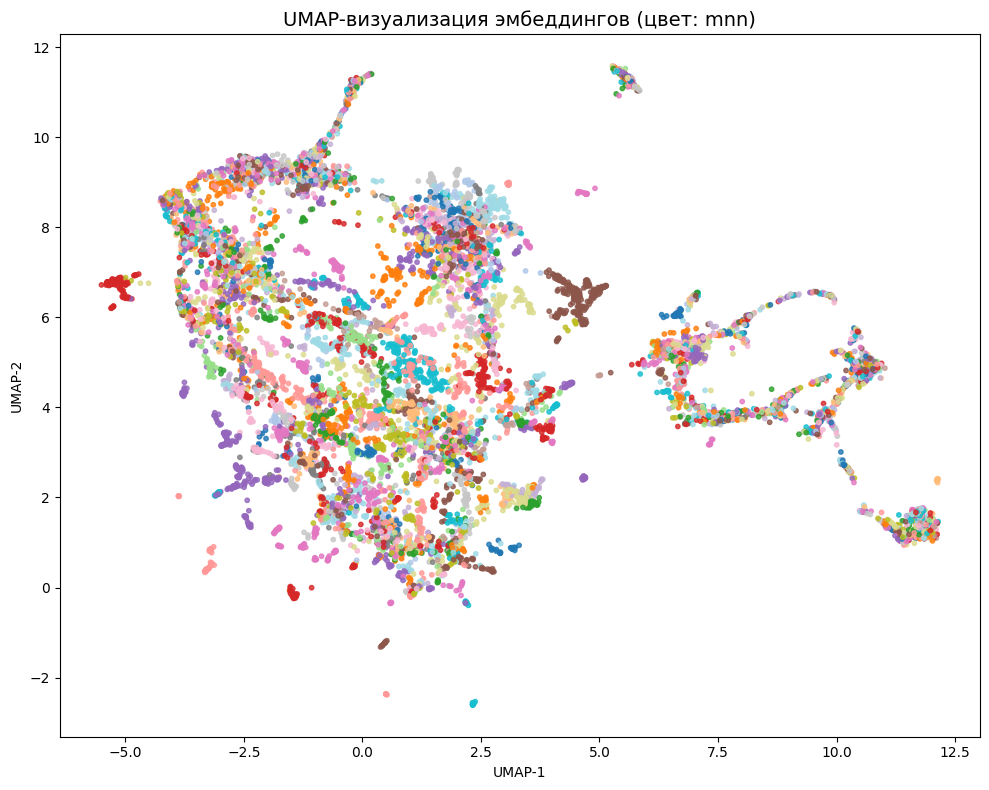

In [ ]:
embeddings = np.load("/content/drive/MyDrive/Colab Notebooks/embedded_chunks/embeddings.npy")
metadata = pd.read_json("/content/drive/MyDrive/Colab Notebooks/embedded_chunks/metadata.json")

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
embedding_2d = reducer.fit_transform(embeddings)

label_column = "mnn"
le = LabelEncoder()
labels = le.fit_transform(metadata[label_column])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    embedding_2d[:, 0], embedding_2d[:, 1],
    c=labels, cmap='tab20', s=10, alpha=0.8 # 20 хорошо различимых цветов
)
plt.title(f"UMAP-визуализация эмбеддингов (цвет: {label_column})", fontsize=14)
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/umap_plot.png", dpi=300)
plt.show()

**Индексация с FAISS и ретривер BM25**

In [ ]:
embeddings_folder = "/content/drive/MyDrive/Colab Notebooks/embedded_chunks"

In [ ]:
class DeepVKEmbeddings(Embeddings):
    def __init__(self, model_name: str = "deepvk/USER-base", device: str = "cuda", batch_size: int = 16):
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name)
        self.device = device
        self.batch_size = batch_size
        self.model.to(device)
        self.model.eval()

    @staticmethod
    def mean_pooling(model_output, attention_mask):
        token_embeddings = model_output.last_hidden_state
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
        sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
        return sum_embeddings / sum_mask

    def embed_documents(self, texts: List[str]) -> List[List[float]]:
        all_embeddings = []
        for i in tqdm(range(0, len(texts), self.batch_size), desc="Векторизация"):
            batch = texts[i:i + self.batch_size]
            inputs = self.tokenizer(batch, return_tensors="pt", truncation=True, padding=True, max_length=512)
            inputs = {k: v.to(self.device) for k, v in inputs.items()}
            with torch.no_grad():
                outputs = self.model(**inputs)
                embeddings = self.mean_pooling(outputs, inputs["attention_mask"]).cpu().numpy()
                all_embeddings.extend(embeddings)
        return all_embeddings

    def embed_query(self, text: str) -> List[float]:
        return self.embed_documents([text])[0]

In [ ]:
embeddings = np.load(os.path.join(embeddings_folder, "embeddings.npy"))
with open(os.path.join(embeddings_folder, "metadata.json"), "r", encoding="utf-8") as f:
    metadata = json.load(f)
with open(os.path.join(embeddings_folder, "texts.json"), "r", encoding="utf-8") as f:
    texts = json.load(f)

In [ ]:
print(f"Количество текстов: {len(texts)}")
print(f"Количество метаданных: {len(metadata)}")
print(f"Пример чанка:\n{texts[0][:500]}")
print(f"Соответствующие метаданные:\n{metadata[0]}")

Количество текстов: 11030
Количество метаданных: 11030
Пример чанка:
не выше 8 °C. Не замораживать. Хранить в оригинальной упаковке для защиты от света. Хранить в недоступном для детей месте! Срок годности 3 года. Не использовать по истечении срока годности. Условия отпуска Отпускают по рецепту. Держатель регистрационного удостоверения Амджен Европа Б.В., Нидерланды Минервум 7061 4817 ZK Бреда Нидерланды Производитель Производитель готовой лекарственной формы/фасовщик (первичная упаковка) Патеон Мэньюфэкчуринг Сервисез ЛЛС, США 5900 Мартин Лютер Кинг Дж. Хайвей, 
Соответствующие метаданные:
{'mnn': 'Карфилзомиб', 'trade_name': 'Кипролис', 'drug_id': 'e5535812-81b4-4643-b41e-9f0e6161a91b', 'file_name': '8ff91800-8349-403e-932e-356adca29b1f.pdf', 'chunk_id': 46}


**FAISS**

In [ ]:
embedding_model = DeepVKEmbeddings(device=device)

In [ ]:
documents = [
    Document(
        page_content=text,
        metadata={**meta, "document_id": i}
    )
    for i, (text, meta) in enumerate(zip(texts, metadata))
]

In [ ]:
faiss_vectorstore = FAISS.from_documents(documents, embedding_model)

In [ ]:
faiss_vectorstore.save_local("/content/drive/MyDrive/Colab Notebooks/faiss")

In [ ]:
faiss_vectorstore = FAISS.load_local(
    "/content/drive/MyDrive/Colab Notebooks/faiss",
    embeddings=embedding_model,
    allow_dangerous_deserialization=True
)

In [ ]:
faiss_retriever = faiss_vectorstore.as_retriever(search_kwargs={"k": 5})

In [ ]:
faiss_retriever.get_relevant_documents("Можно ли принимать Метортрит при беременности?")

Векторизация: 100%|██████████| 1/1 [00:00<00:00, 28.91it/s]


[Document(id='4f4e6a72-c121-4a7d-8176-12d407975276', metadata={'mnn': 'Метотрексат', 'trade_name': 'Метортрит', 'drug_id': '164d094a-1d50-46cc-a2ef-482857414d27', 'file_name': 'ca1d437c-e004-4b16-ad92-37679984cfa8.pdf', 'chunk_id': 4, 'document_id': 2994}, page_content='с грудным молоком. Ввиду риска серьезных неблагоприятных реакций у младенцев, находящихся на грудном вскармливании, препарат Метортрит противопоказан в период грудного вскармливания (см. раздел «Противопоказания»), поэтому следует прекратить грудное вскармливание перед началом лечения метотрексатом и воздерживаться от него в течение всего курса лечения. Способ применения и дозы Препарат Метортрит применяют подкожно, внутримышечно или внутривенно (у детей до 18 лет только подкожно или внутримышечно). Входящая в состав упаковки игла для инъекций предназначена только для подкожного введения препарата Метортрит! Для введения препарата внут- римышечно или внутривенно необходимо использовать иглы, подходящие для этих путей вв

**BM25 Retriever**

In [ ]:
documents = [
    Document(
        page_content=text,
        metadata={**meta, "document_id": i}
    )
    for i, (text, meta) in enumerate(zip(texts, metadata))
]

In [ ]:
bm25_retriever = BM25Retriever.from_documents(documents)
bm25_retriever.k = 5

<img src="bm25.png" style="width:100%;" />

In [ ]:
bm25_retriever.get_relevant_documents("Можно ли принимать Метортрит при беременности?")

[Document(metadata={'mnn': 'Метотрексат', 'trade_name': 'Метортрит', 'drug_id': '164d094a-1d50-46cc-a2ef-482857414d27', 'file_name': 'ca1d437c-e004-4b16-ad92-37679984cfa8.pdf', 'chunk_id': 4, 'document_id': 2994}, page_content='с грудным молоком. Ввиду риска серьезных неблагоприятных реакций у младенцев, находящихся на грудном вскармливании, препарат Метортрит противопоказан в период грудного вскармливания (см. раздел «Противопоказания»), поэтому следует прекратить грудное вскармливание перед началом лечения метотрексатом и воздерживаться от него в течение всего курса лечения. Способ применения и дозы Препарат Метортрит применяют подкожно, внутримышечно или внутривенно (у детей до 18 лет только подкожно или внутримышечно). Входящая в состав упаковки игла для инъекций предназначена только для подкожного введения препарата Метортрит! Для введения препарата внут- римышечно или внутривенно необходимо использовать иглы, подходящие для этих путей введения! Препарат Метортрит не следует смеши

**Ensemble Retrievers**


In [ ]:
faiss_retriever = faiss_vectorstore.as_retriever(search_kwargs={"k": 5})
bm25_retriever.k = 5

ensemble_retriever = EnsembleRetriever(
    retrievers=[
        faiss_retriever,
        bm25_retriever
    ],
    weights=[0.7, 0.3]
)

In [ ]:
ensemble_retriever.get_relevant_documents("Какие противопоказания существуют для приема Сотрета?")

Векторизация: 100%|██████████| 1/1 [00:00<00:00, 35.91it/s]


[Document(id='3a9fed49-225a-4fdf-a33f-4fb5ba781f34', metadata={'mnn': 'Третиноин', 'trade_name': 'Сотрет', 'drug_id': 'cd74be9f-5347-4987-a31b-4f4a17b5aa11', 'file_name': '95cadf0d-e462-4130-b24d-088cf9975fe6.pdf', 'chunk_id': 1, 'document_id': 3411}, page_content='конглобатные акне или акне с риском образования рубцов); — акне, не поддающиеся другим видам терапии. Если улучшение не наступило или Вы чувствуете ухудшение, необходимо обратиться к врачу. Принимать препарат Сотрет возможно только под наблюдением врача. 2. О чем следует знать перед приемом препарата Сотрет Противопоказания Не принимайте препарат Сотрет: е Если Вы беременны или кормите грудью,. е Если есть вероятность, что Вы можете забеременеть. Вы должны следовать указаниям Программы по предотвращению беременности (см. раздел «Особые указания и меры предосторожности» листка—вкладыша). е Если у Вас аллергия на изотретинойин. Если у Вас аллергия на любые другие компоненты препарата (перечисленные в разделе 6 листка—вкладыша)